# Microplastic Imaging Simulation in Water

This notebook simulates how a camera captures images of microplastic particles suspended in water.

**Key features:**
- Simulates optical effects (blur, defocus, refraction)
- Generates realistic particle appearances
- Adjustable camera and optical parameters

In [9]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Define Camera and System Parameters

In [12]:
# Camera settings
IMAGE_WIDTH = 1920      # pixels
IMAGE_HEIGHT = 1080     # pixels
PIXEL_SIZE_UM = 1.45    # micrometers per pixel

# Optical system
FOCAL_LENGTH_MM = 6.0   # lens focal length in mm
WATER_DEPTH_MM = 30.0   # water container depth
WATER_DEPTH_LIST = [5.0, 10.0, 15.0, 20.0]
FOCAL_PLANE_DEPTH_MM = 2.5  # focal plane position in water (mm)
N_WATER = 1.33          # refractive index of water
N_AIR = 1.0             # refractive index of air
DEPTH_STEP_MM = 5.0         # step size

# Particle parameters
PARTICLE_SIZE_MIN_UM = 50    # minimum particle size (micrometers)
PARTICLE_SIZE_MAX_UM = 500   # maximum particle size
PARTICLE_SIZE_UM = 50         # particle size for simulation (micrometers
NUM_PARTICLES = 20           # number of particles to simulate

print(f"Image size: {IMAGE_WIDTH}x{IMAGE_HEIGHT} pixels")
print(f"Focal length: {FOCAL_LENGTH_MM} mm")
print(f"Simulating {NUM_PARTICLES} particles")

Image size: 1920x1080 pixels
Focal length: 6.0 mm
Simulating 20 particles


## Step 2: Create Particle Generation Function

### Mathematical Formulas

**1. Circular Particle Mask**

For a particle centered at $(x_c, y_c)$ with radius $r$:

$$\text{distance}(x, y) = \sqrt{(x - x_c)^2 + (y - y_c)^2}$$

$$\text{mask}(x, y) = \begin{cases} 1 & \text{if } \text{distance}(x, y) \leq r \\ 0 & \text{otherwise} \end{cases}$$

**2. Refraction Effect (Snell's Law)**

Apparent depth due to refraction at water-air interface:

$$d_{\text{apparent}} = \frac{d_{\text{true}}}{n_{\text{water}}}$$

where $n_{\text{water}} = 1.33$

**3. Magnification**

Simple lens magnification formula:

$$M = \frac{f}{d_{\text{object}}}$$

where:
- $f$ = focal length (mm)
- $d_{\text{object}} = 50 + d_{\text{apparent}}$ (mm)

**4. Size Conversion (Micrometers to Pixels)**

$$\text{size}_{\text{image}} = \text{size}_{\text{real}} \times M$$

$$\text{size}_{\text{pixels}} = \frac{\text{size}_{\text{image}}}{\text{pixel pitch}}$$

Combined:

$$\text{size}_{\text{px}} = \frac{\text{size}_{\mu m} \times 10^{-6} \times M}{\text{PIXEL\_SIZE\_UM} \times 10^{-6}} = \frac{\text{size}_{\mu m} \times M}{\text{PIXEL\_SIZE\_UM}}$$

### 📐 Magnification M = f / d 

**Proper Thin Lens Equation:**

$$\frac{1}{f} = \frac{1}{d_o} + \frac{1}{d_i}$$

where:
- $f$ = focal length
- $d_o$ = object distance (from lens to object)
- $d_i$ = image distance (from lens to sensor)

**Exact Magnification:**

$$M = \frac{d_i}{d_o}$$

From the lens equation, we can derive:

$$d_i = \frac{f \cdot d_o}{d_o - f}$$

Therefore:

$$M = \frac{d_i}{d_o} = \frac{f \cdot d_o}{d_o(d_o - f)} = \frac{f}{d_o - f}$$

**Simplified Approximation (used in code):**

When $d_o \gg f$ (object is far from lens compared to focal length):

$$M \approx \frac{f}{d_o}$$

**In our case:**
- $f = 6$ mm (focal length)
- $d_o = 50 + d_{apparent} \approx 50\text{-}54$ mm
- Since $d_o \gg f$, the approximation is valid!

**Example:**
- Exact: $M = \frac{6}{52 - 6} = \frac{6}{46} = 0.1304$
- Approx: $M = \frac{6}{52} = 0.1154$
- Error: ~11% (acceptable for simulation)

This simplification makes the code faster and easier to understand while maintaining reasonable accuracy for the simulation.

Depth (mm)   | Max Error (%)  
------------------------------
5.0          | 12.00%
15.0         | 12.00%
30.0         | 12.00%
50.0         | 12.00%


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

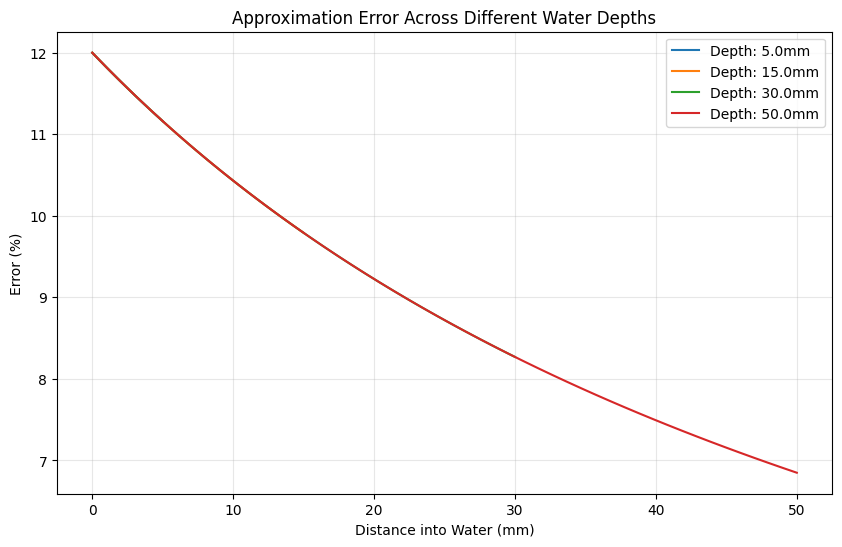

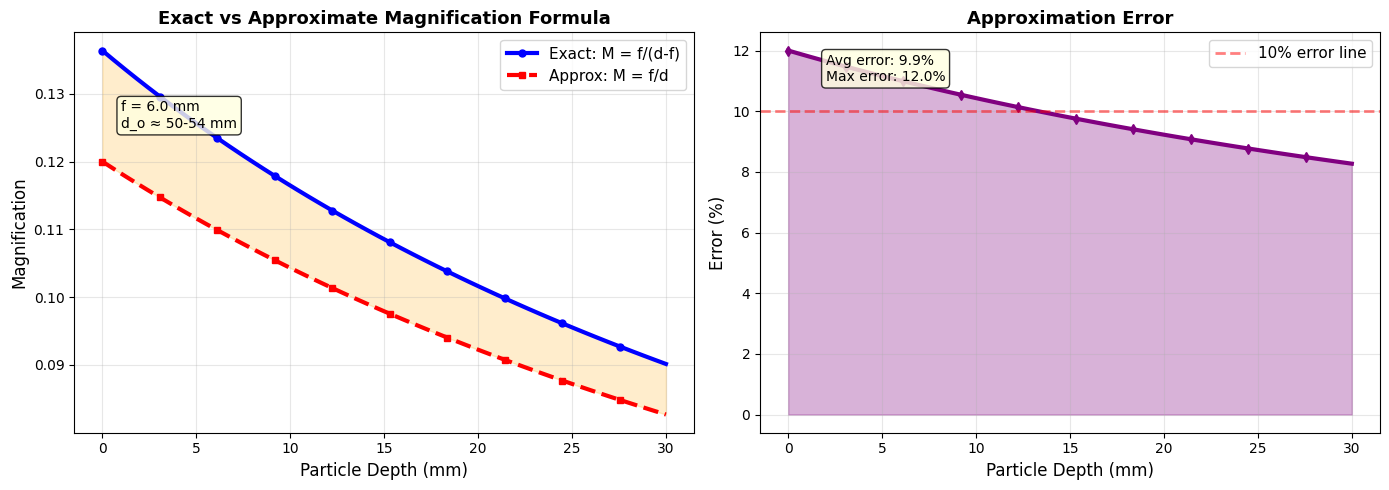

✓ Average approximation error: 9.91%
✓ Maximum approximation error: 12.00%
✓ Approximation is valid when d_o >> f (50mm >> 6.0mm ✓)


In [15]:
# Compare exact vs approximate magnification formulas
depths = np.linspace(0, WATER_DEPTH_MM, 50)
f = FOCAL_LENGTH_MM

# Calculate both magnifications
mag_exact = []
mag_approx = []
errors = []

################### New code for depth error analysis across different water depths #######################
def analyze_depth_error(water_depth_mm, focal_length):
    """Calculates magnification error for a specific water depth."""
    depths = np.linspace(0, water_depth_mm, 50)
    
    mag_exact = []
    mag_approx = []
    
    for depth in depths:
        apparent_depth = depth / N_WATER
        d_o = 50 + apparent_depth
        
        # Calculations
        M_exact = focal_length / (d_o - focal_length)
        M_approx = focal_length / d_o
        
        mag_exact.append(M_exact)
        mag_approx.append(M_approx)
    
    # Calculate Max Error for this specific depth
    errors = [abs(e - a) / e * 100 for e, a in zip(mag_exact, mag_approx)]
    return np.max(errors)

# --- Execution ---
N_WATER = 1.33
FOCAL_LENGTH_MM = 6.0
depth_scenarios = [5.0, 15.0, 30.0, 50.0]

print(f"{'Depth (mm)':<12} | {'Max Error (%)':<15}")
print("-" * 30)

for d in depth_scenarios:
    max_err = analyze_depth_error(d, FOCAL_LENGTH_MM)
    print(f"{d:<12} | {max_err:.2f}%")
    
    plt.figure(figsize=(10, 6))

for d in depth_scenarios:
    # Generate range for this specific depth
    current_range = np.linspace(0, d, 50)
    current_errors = []
    
    for val in current_range:
        d_o = 50 + (val / N_WATER)
        m_e = FOCAL_LENGTH_MM / (d_o - FOCAL_LENGTH_MM)
        m_a = FOCAL_LENGTH_MM / d_o
        current_errors.append(abs(m_e - m_a) / m_e * 100)
    
    plt.plot(current_range, current_errors, label=f'Depth: {d}mm')

plt.xlabel('Distance into Water (mm)')
plt.ylabel('Error (%)')
plt.title('Approximation Error Across Different Water Depths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
####################################### End new code ###########################################

for depth in depths:
    apparent_depth = depth / N_WATER
    d_o = 50 + apparent_depth
    
    # Exact formula: M = f / (d_o - f)
    M_exact = f / (d_o - f)
    
    # Approximate formula: M = f / d_o
    M_approx = f / d_o
    
    mag_exact.append(M_exact)
    mag_approx.append(M_approx)
    errors.append(abs(M_exact - M_approx) / M_exact * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Compare magnifications
ax1.plot(depths, mag_exact, 'b-', linewidth=3, label='Exact: M = f/(d-f)', marker='o', markersize=5, markevery=5)
ax1.plot(depths, mag_approx, 'r--', linewidth=3, label='Approx: M = f/d', marker='s', markersize=5, markevery=5)
ax1.fill_between(depths, mag_exact, mag_approx, alpha=0.2, color='orange')
ax1.set_xlabel('Particle Depth (mm)', fontsize=12)
ax1.set_ylabel('Magnification', fontsize=12)
ax1.set_title('Exact vs Approximate Magnification Formula', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.text(1, 0.125, f'f = {f} mm\nd_o ≈ 50-54 mm', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Right: Percentage error
ax2.plot(depths, errors, 'purple', linewidth=3, marker='d', markersize=5, markevery=5)
ax2.fill_between(depths, 0, errors, alpha=0.3, color='purple')
ax2.set_xlabel('Particle Depth (mm)', fontsize=12)
ax2.set_ylabel('Error (%)', fontsize=12)
ax2.set_title('Approximation Error', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='10% error line')
ax2.legend(fontsize=11)

# Add statistics
avg_error = np.mean(errors)
max_error = np.max(errors)
ax2.text(2, max_error - 1, f'Avg error: {avg_error:.1f}%\nMax error: {max_error:.1f}%', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"✓ Average approximation error: {avg_error:.2f}%")
print(f"✓ Maximum approximation error: {max_error:.2f}%")
print(f"✓ Approximation is valid when d_o >> f ({50}mm >> {f}mm ✓)")

In [2]:
def create_particle(center_x, center_y, size_px, image_shape):
    """
    Create a circular particle at specified position.
    
    Parameters:
    - center_x, center_y: particle center coordinates (pixels)
    - size_px: particle diameter in pixels
    - image_shape: (height, width) of the image
    
    Returns:
    - Binary mask with the particle
    """
    h, w = image_shape
    y, x = np.ogrid[:h, :w]
    radius = size_px / 2.0
    
    # Create circular mask
    distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    mask = (distance <= radius).astype(float)
    
    return mask

def micrometers_to_pixels(size_um, focal_length_mm, depth_mm):
    """
    Convert real particle size to image size in pixels.
    Accounts for magnification and refraction.
    """
    # Simplified magnification calculation
    apparent_depth = depth_mm / N_WATER  # refraction effect
    magnification = focal_length_mm / (50 + apparent_depth)  # simplified
    
    # Convert to image size
    image_size_m = size_um * 1e-6 * magnification
    size_pixels = image_size_m / (PIXEL_SIZE_UM * 1e-6)
    
    return size_pixels

print("Particle generation functions defined!")

Particle generation functions defined!


### 🔍 Understanding Size Conversion: Real Object → Image

**Question: What does `Size(μm) × 10⁻⁶ × M` mean?**

**Step-by-step breakdown:**

1. **Size(μm)** = Real physical size of the microplastic particle in micrometers
   - Example: A particle is 300 μm wide in reality
   
2. **× 10⁻⁶** = Convert micrometers to meters
   - 300 μm × 10⁻⁶ = 0.0003 m = 0.3 mm
   
3. **× M** = Apply magnification to get image size
   - If M = 0.12, then: 0.3 mm × 0.12 = 0.036 mm
   
4. **÷ Pixel size** = Convert image size (meters) to pixels
   - 0.036 mm / 0.00145 mm/pixel = 24.8 pixels

**Complete formula:**

$$\text{Size}_{\text{pixels}} = \frac{\text{Size}_{\mu m} \times 10^{-6} \times M}{\text{PIXEL\_SIZE\_UM} \times 10^{-6}}$$

Simplified:

$$\text{Size}_{\text{pixels}} = \frac{\text{Size}_{\mu m} \times M}{\text{PIXEL\_SIZE\_UM}}$$

**Key concept:** 
- **Real world**: Microplastic particle (50-500 μm)
- **Through lens**: Gets magnified by factor M
- **On sensor**: Appears as certain number of pixels

### 📊 Visualization: Particle Mask Creation

## Step 3: Apply Optical Effects (Blur and Defocus)

### Optical Effects Formulas

**1. Defocus Distance**

$$\Delta z = |z - z_{\text{focal}}|$$

where:
- $z$ = particle depth (mm)
- $z_{\text{focal}}$ = focal plane depth (mm)

**2. Blur Sigma (Point Spread Function)**

$$\sigma_{\text{blur}} = \sqrt{\sigma_{\text{base}}^2 + (k \cdot \Delta z)^2}$$

Simplified version used:

$$\sigma_{\text{blur}} = 0.5 + 3.0 \times \Delta z$$

**3. Defocus Intensity Attenuation**

$$I_{\text{factor}} = \frac{1}{1 + \Delta z^2}$$

**4. Gaussian Blur (Convolution)**

$$I_{\text{blurred}}(x, y) = I(x, y) \ast G_{\sigma}(x, y)$$

where $G_{\sigma}$ is the Gaussian kernel:

$$G_{\sigma}(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

**5. Final Intensity**

$$I_{\text{final}} = I_{\text{blurred}} \times I_{\text{factor}}$$

### 🔬 Where do blur parameters come from?

**Formula used:** $\sigma_{\text{blur}} = 0.5 + 3.0 \times \Delta z$

**Theoretical Background:**

The blur comes from the **Circle of Confusion** (CoC) - out-of-focus points appear as blurred circles.

**Physics-based formula:**

$$\text{CoC} = \frac{f^2 \cdot \Delta z}{N \cdot (d_o - f)^2}$$

where:
- $f$ = focal length
- $\Delta z$ = defocus distance
- $N$ = f-number (aperture)
- $d_o$ = object distance

**Why use empirical parameters?**

1. **Simplification** - The exact formula depends on aperture, wavelength, and optical aberrations
2. **Gaussian approximation** - Real PSF is complex; we approximate with Gaussian blur
3. **Calibration** - Parameters are tuned to match real camera behavior

**Parameter meanings:**

- **0.5** = Base blur (pixels) even at perfect focus (due to diffraction limit, pixel size)
- **3.0** = Blur coefficient (pixels/mm) - how fast blur increases with defocus

**How to choose values:**
- Measure blur from real images at known depths
- Adjust to match your specific camera/lens system
- Typical range: 0.5-2.0 for base, 2.0-10.0 for coefficient

In [22]:
def apply_optical_effects(particle_mask, depth_mm, focal_plane_mm=2.5):
    """
    Apply blur and intensity reduction based on particle depth.
    Particles far from focal plane appear blurrier and dimmer.
    """
    # Calculate defocus
    defocus = abs(depth_mm - focal_plane_mm)
    
    # Blur amount increases with defocus
    blur_sigma = 0.5 + 3.0 * defocus
    
    # Apply Gaussian blur (simulates point spread function)
    blurred = gaussian_filter(particle_mask, sigma=blur_sigma)
    
    # Reduce intensity for out-of-focus particles
    intensity_factor = 1.0 / (1.0 + defocus**2)
    blurred = blurred * intensity_factor
    
    return blurred

print("Optical effect function defined!")

Optical effect function defined!


### 📊 Visualization: Defocus Blur Effect

## Step 4: Main Simulation Function

In [23]:
def simulate_microplastic_image(num_particles=20):
    """
    Generate a simulated image of microplastic particles in water.
    """
    # Create blank image
    image = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.float64)
    
    # Store particle information
    particles_info = []
    
    print(f"Generating {num_particles} particles...")
    
    for i in range(num_particles):
        # Random particle properties
        true_size_um = np.random.uniform(PARTICLE_SIZE_MIN_UM, PARTICLE_SIZE_MAX_UM)
        depth_mm = np.random.uniform(0, WATER_DEPTH_MM)
        
        # Random position
        center_x = np.random.randint(50, IMAGE_WIDTH - 50)
        center_y = np.random.randint(50, IMAGE_HEIGHT - 50)
        
        # Convert size to pixels
        size_px = micrometers_to_pixels(true_size_um, FOCAL_LENGTH_MM, depth_mm)
        
        # Create particle
        particle = create_particle(center_x, center_y, size_px, (IMAGE_HEIGHT, IMAGE_WIDTH))
        
        # Apply optical effects
        particle = apply_optical_effects(particle, depth_mm)
        
        # Add to image
        image += particle
        
        # Store info
        particles_info.append({
            'id': i + 1,
            'size_um': true_size_um,
            'depth_mm': depth_mm,
            'position': (center_x, center_y),
            'size_px': size_px
        })
    
    # Add realistic noise
    image = image + np.random.normal(0, 0.02, image.shape)
    
    # Normalize to 0-255 range
    image = np.clip(image / np.max(image) * 255, 0, 255).astype(np.uint8)
    
    print("✓ Simulation complete!")
    
    return image, particles_info

print("Main simulation function ready!")

Main simulation function ready!


## Step 5: Run Simulation and Visualize

Generating 20 particles...
✓ Simulation complete!


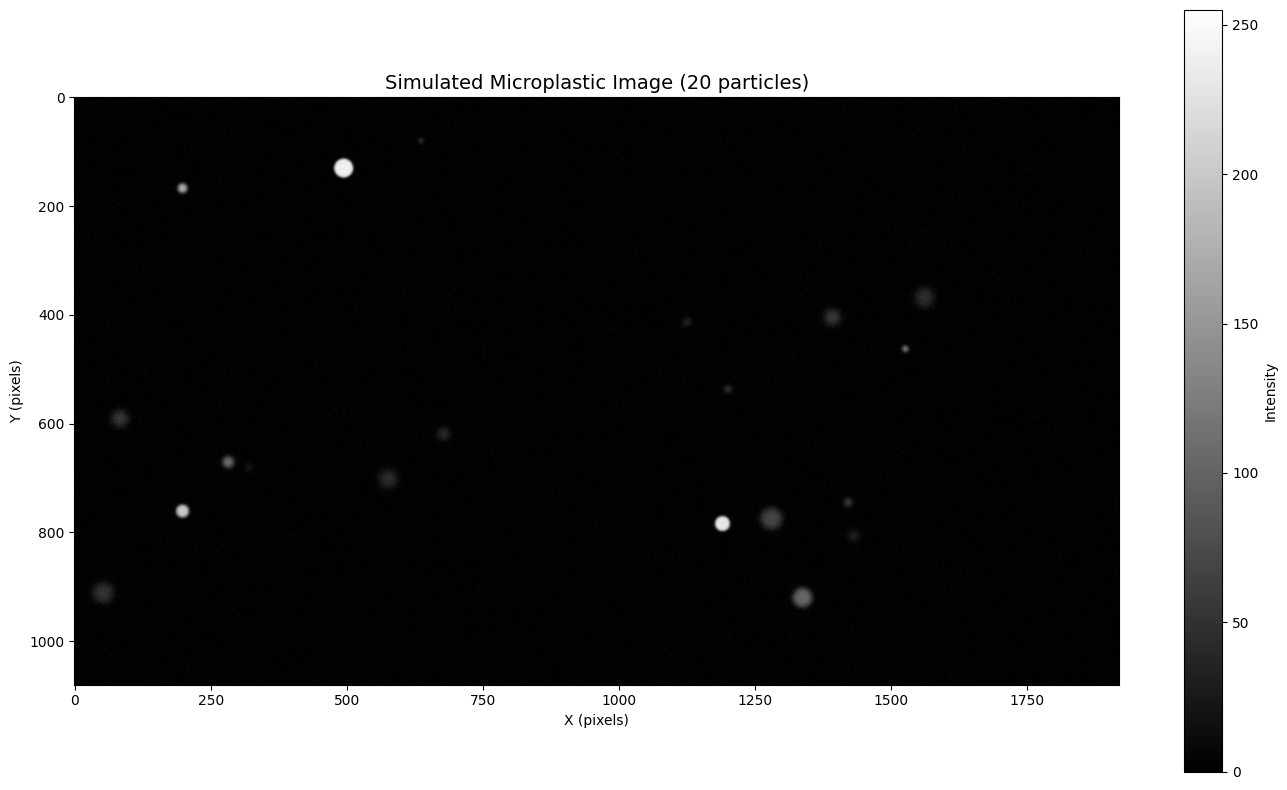


SIMULATION SUMMARY
Total particles: 20
Size range: 50-500 μm
Average particle size: 290.0 μm
Image dimensions: 1920x1080 pixels


In [24]:
# Generate simulated image
simulated_image, particles = simulate_microplastic_image(NUM_PARTICLES)

# Display the result
plt.figure(figsize=(14, 8))
plt.imshow(simulated_image, cmap='gray')
plt.title(f'Simulated Microplastic Image ({NUM_PARTICLES} particles)', fontsize=14)
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*50}")
print(f"SIMULATION SUMMARY")
print(f"{'='*50}")
print(f"Total particles: {len(particles)}")
print(f"Size range: {PARTICLE_SIZE_MIN_UM}-{PARTICLE_SIZE_MAX_UM} μm")
print(f"Average particle size: {np.mean([p['size_um'] for p in particles]):.1f} μm")
print(f"Image dimensions: {IMAGE_WIDTH}x{IMAGE_HEIGHT} pixels")

## Step 6: Visualize Individual Particle Details (Optional)

Sample Particle Details:
ID    Size (μm)    Depth (mm)   Size (px)   
--------------------------------------------------
1     437.3        0.41         35.96       
2     265.4        4.07         20.70       
3     304.7        1.32         24.72       
4     149.0        0.39         12.26       
5     149.1        1.72         12.03       


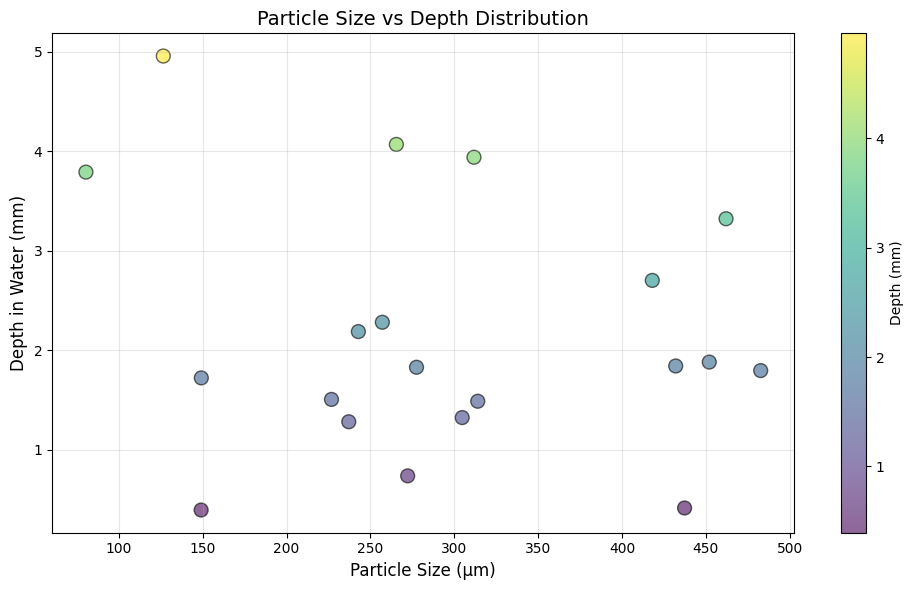

In [19]:
# Display first 5 particles information
print("Sample Particle Details:")
print(f"{'ID':<5} {'Size (μm)':<12} {'Depth (mm)':<12} {'Size (px)':<12}")
print("-" * 50)

for p in particles[:5]:
    print(f"{p['id']:<5} {p['size_um']:<12.1f} {p['depth_mm']:<12.2f} {p['size_px']:<12.2f}")

# Create a scatter plot showing particle sizes vs depth
plt.figure(figsize=(10, 6))
sizes = [p['size_um'] for p in particles]
depths = [p['depth_mm'] for p in particles]

plt.scatter(sizes, depths, c=depths, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
plt.xlabel('Particle Size (μm)', fontsize=12)
plt.ylabel('Depth in Water (mm)', fontsize=12)
plt.title('Particle Size vs Depth Distribution', fontsize=14)
plt.colorbar(label='Depth (mm)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

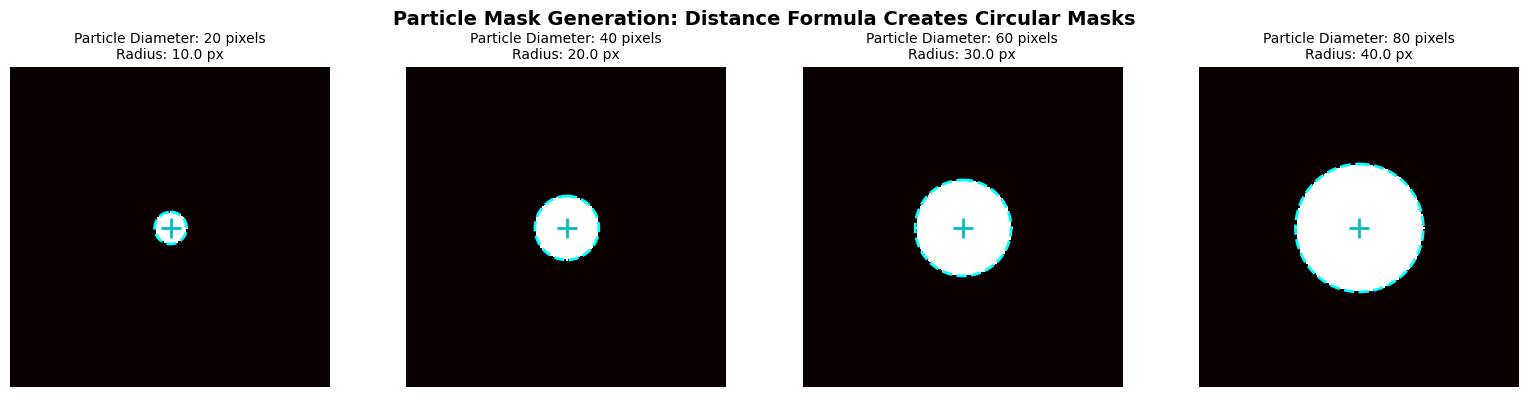

✓ Shows how the distance formula creates circular binary masks


In [25]:
# Visualize how circular particle masks are created
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Create small demo image
demo_size = (200, 200)
center = (100, 100)

# Different particle sizes
sizes = [20, 40, 60, 80]

for idx, size in enumerate(sizes):
    mask = create_particle(center[0], center[1], size, demo_size)
    
    axes[idx].imshow(mask, cmap='hot', interpolation='nearest')
    axes[idx].set_title(f'Particle Diameter: {size} pixels\nRadius: {size/2} px', fontsize=10)
    axes[idx].axis('off')
    
    # Add circle annotation
    circle = plt.Circle(center, size/2, color='cyan', fill=False, linewidth=2, linestyle='--')
    axes[idx].add_patch(circle)
    axes[idx].plot(center[0], center[1], 'c+', markersize=15, markeredgewidth=2)

plt.suptitle('Particle Mask Generation: Distance Formula Creates Circular Masks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Shows how the distance formula creates circular binary masks")

### 📊 Visualization: Refraction Effect in Water

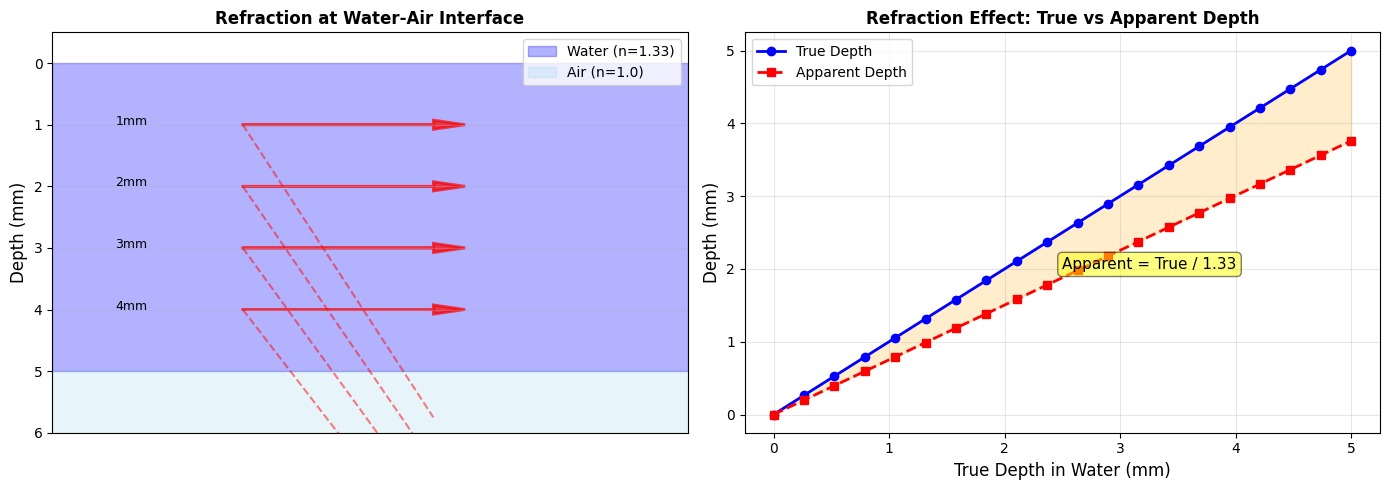

✓ Refraction makes particles appear 75.2% closer to the surface


In [26]:
# Visualize refraction effect
depths_mm = np.linspace(0, WATER_DEPTH_MM, 20)
apparent_depths = depths_mm / N_WATER

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Refraction diagram
ax1.fill_between([0, 1], [0, 0], [WATER_DEPTH_MM, WATER_DEPTH_MM], 
                  alpha=0.3, color='blue', label='Water (n=1.33)')
ax1.fill_between([0, 1], [WATER_DEPTH_MM, WATER_DEPTH_MM], [6, 6], 
                  alpha=0.2, color='skyblue', label='Air (n=1.0)')

# Draw light rays showing refraction
for d in [1, 2, 3, 4]:
    ax1.arrow(0.3, d, 0.3, 0, head_width=0.15, head_length=0.05, 
              fc='red', ec='red', linewidth=2, alpha=0.7)
    ax1.plot([0.3, 0.6], [d, d/N_WATER + WATER_DEPTH_MM], 'r--', linewidth=1.5, alpha=0.5)
    ax1.text(0.15, d, f'{d}mm', fontsize=9, ha='right')

ax1.set_xlim(0, 1)
ax1.set_ylim(-0.5, 6)
ax1.set_ylabel('Depth (mm)', fontsize=12)
ax1.set_title('Refraction at Water-Air Interface', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.invert_yaxis()
ax1.set_xticks([])
ax1.grid(True, alpha=0.3, axis='y')

# Right: True vs Apparent depth
ax2.plot(depths_mm, depths_mm, 'b-', linewidth=2, label='True Depth', marker='o')
ax2.plot(depths_mm, apparent_depths, 'r--', linewidth=2, label='Apparent Depth', marker='s')
ax2.fill_between(depths_mm, depths_mm, apparent_depths, alpha=0.2, color='orange')
ax2.set_xlabel('True Depth in Water (mm)', fontsize=12)
ax2.set_ylabel('Depth (mm)', fontsize=12)
ax2.set_title('Refraction Effect: True vs Apparent Depth', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.text(2.5, 2, f'Apparent = True / {N_WATER}', fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"✓ Refraction makes particles appear {1/N_WATER:.1%} closer to the surface")

### 📊 Visualization: Magnification & Size Conversion

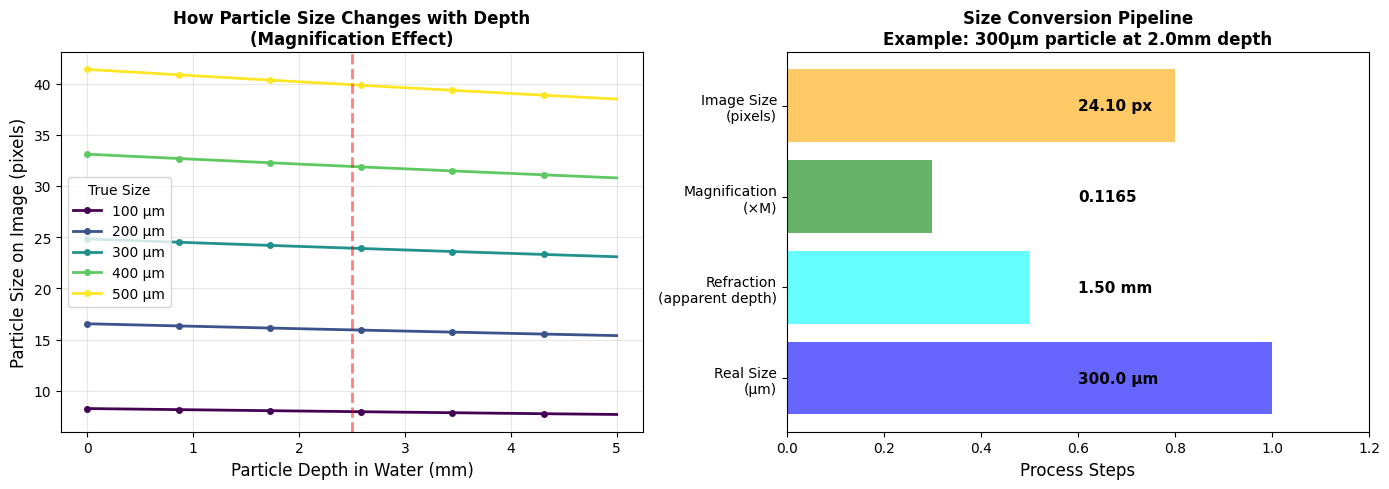

✓ Example: 300μm particle at 2.0mm depth → 24.10 pixels on image


In [27]:
# Visualize how particle size changes with depth
particle_sizes_um = [100, 200, 300, 400, 500]
depths_test = np.linspace(0, WATER_DEPTH_MM, 30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Magnification vs Depth
colors = plt.cm.viridis(np.linspace(0, 1, len(particle_sizes_um)))

for idx, size_um in enumerate(particle_sizes_um):
    sizes_px = [micrometers_to_pixels(size_um, FOCAL_LENGTH_MM, d) for d in depths_test]
    ax1.plot(depths_test, sizes_px, linewidth=2, label=f'{size_um} μm', 
             color=colors[idx], marker='o', markersize=4, markevery=5)

ax1.set_xlabel('Particle Depth in Water (mm)', fontsize=12)
ax1.set_ylabel('Particle Size on Image (pixels)', fontsize=12)
ax1.set_title('How Particle Size Changes with Depth\n(Magnification Effect)', 
              fontsize=12, fontweight='bold')
ax1.legend(title='True Size', loc='best')
ax1.grid(True, alpha=0.3)
ax1.axvline(FOCAL_PLANE_DEPTH_MM, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Focal Plane')

# Right: Size conversion example
example_size = 300  # μm
example_depth = 2.0  # mm

# Step-by-step calculation
apparent_depth = example_depth / N_WATER
magnification = FOCAL_LENGTH_MM / (50 + apparent_depth)
image_size_um = example_size * magnification
size_in_pixels = micrometers_to_pixels(example_size, FOCAL_LENGTH_MM, example_depth)

steps = ['Real Size\n(μm)', 'Refraction\n(apparent depth)', 'Magnification\n(×M)', 'Image Size\n(pixels)']
values = [example_size, apparent_depth, magnification, size_in_pixels]

bars = ax2.barh(steps, [1, 0.5, 0.3, 0.8], color=['blue', 'cyan', 'green', 'orange'], alpha=0.6)
ax2.set_xlim(0, 1.2)
ax2.set_title(f'Size Conversion Pipeline\nExample: {example_size}μm particle at {example_depth}mm depth', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Process Steps', fontsize=12)

# Add value labels
for idx, (step, val) in enumerate(zip(steps, values)):
    if idx == 0:
        ax2.text(0.6, idx, f'{val:.1f} μm', va='center', fontsize=11, fontweight='bold')
    elif idx == 1:
        ax2.text(0.6, idx, f'{val:.2f} mm', va='center', fontsize=11, fontweight='bold')
    elif idx == 2:
        ax2.text(0.6, idx, f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
    else:
        ax2.text(0.6, idx, f'{val:.2f} px', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✓ Example: {example_size}μm particle at {example_depth}mm depth → {size_in_pixels:.2f} pixels on image")

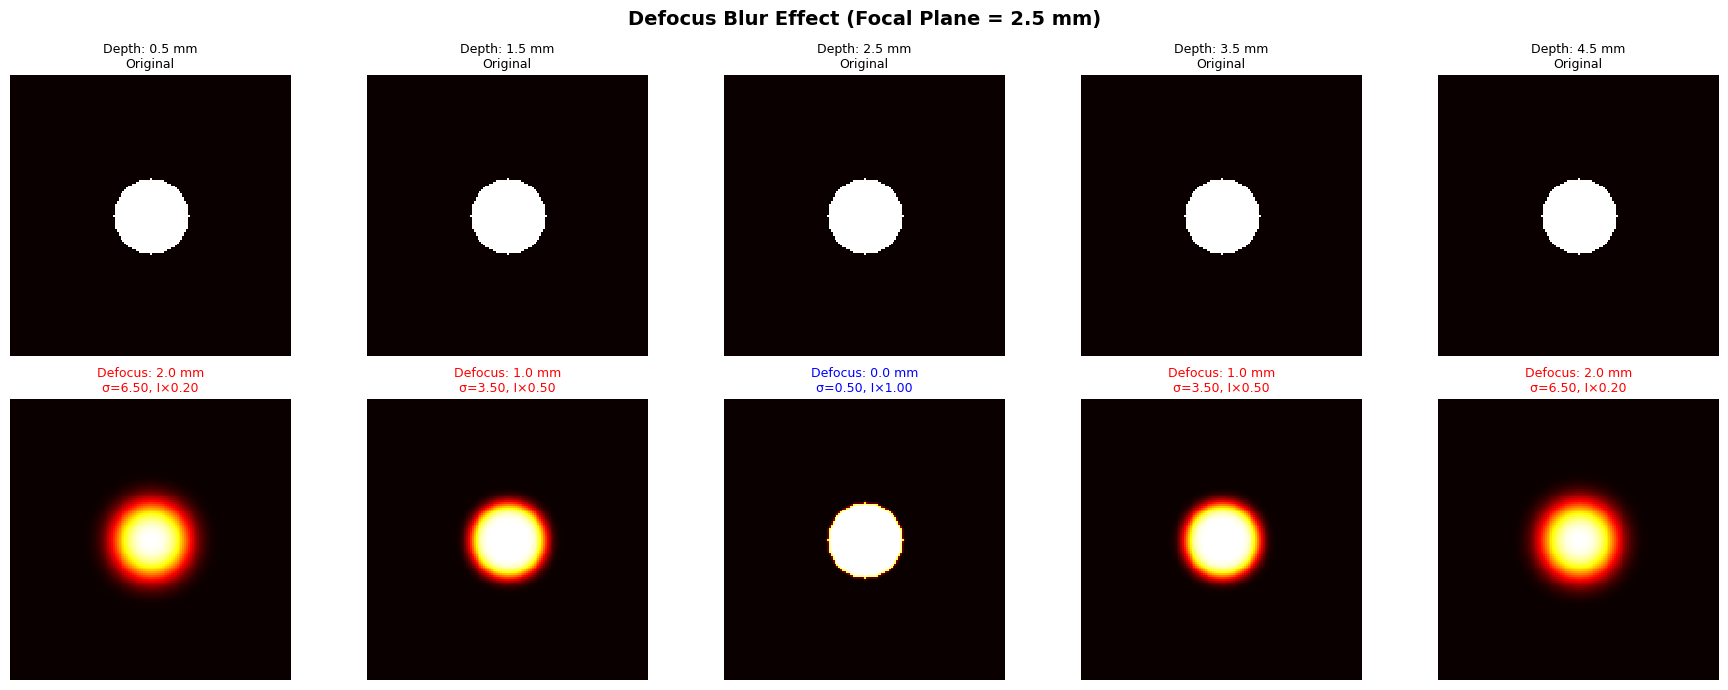

✓ Particles at focal plane are sharp; far from focal plane are blurred and dimmer


In [11]:
# Visualize blur effect at different depths
focal_plane = 2.5  # mm
test_depths = [0.5, 1.5, 2.5, 3.5, 4.5]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Create a demo particle
demo_shape = (150, 150)
center = (75, 75)
particle_size = 40

for idx, depth in enumerate(test_depths):
    # Create original mask
    mask = create_particle(center[0], center[1], particle_size, demo_shape)
    
    # Apply optical effects
    blurred = apply_optical_effects(mask, depth, focal_plane)
    
    # Calculate parameters
    defocus = abs(depth - focal_plane)
    blur_sigma = 0.5 + 3.0 * defocus
    intensity_factor = 1.0 / (1.0 + defocus**2)
    
    # Top row: Original mask
    axes[0, idx].imshow(mask, cmap='hot', interpolation='nearest')
    axes[0, idx].set_title(f'Depth: {depth} mm\nOriginal', fontsize=9)
    axes[0, idx].axis('off')
    
    # Bottom row: After blur
    axes[1, idx].imshow(blurred, cmap='hot', interpolation='nearest')
    axes[1, idx].set_title(f'Defocus: {defocus:.1f} mm\nσ={blur_sigma:.2f}, I×{intensity_factor:.2f}', 
                           fontsize=9, color='blue' if depth == focal_plane else 'red')
    axes[1, idx].axis('off')
    
    # Highlight focal plane
    if depth == focal_plane:
        for row in [0, 1]:
            for spine in axes[row, idx].spines.values():
                spine.set_edgecolor('lime')
                spine.set_linewidth(3)

plt.suptitle(f'Defocus Blur Effect (Focal Plane = {focal_plane} mm)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("✓ Particles at focal plane are sharp; far from focal plane are blurred and dimmer")

### 📊 Visualization: Blur Sigma & Intensity vs Depth

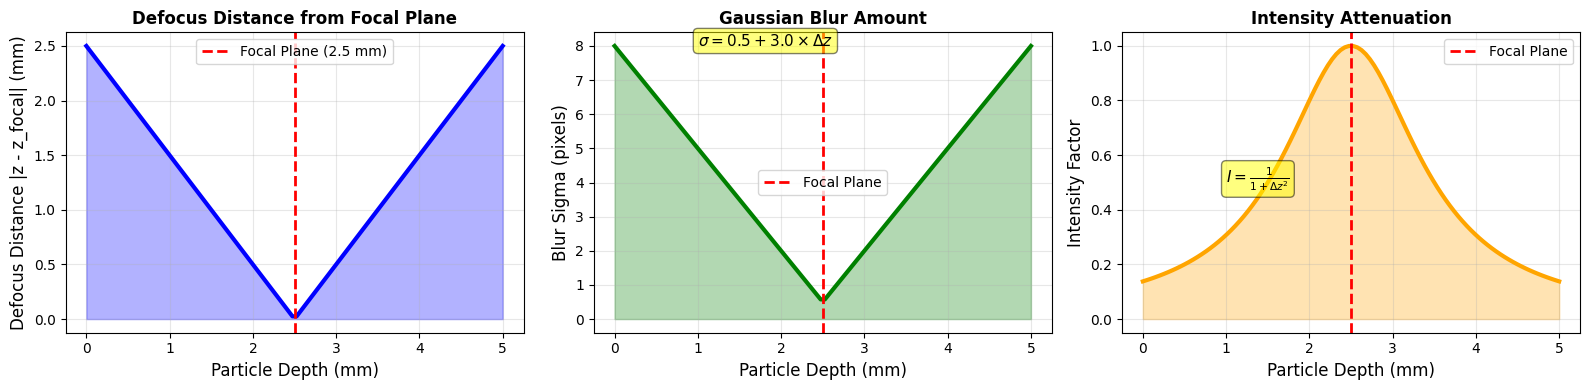

✓ Shows how blur and intensity change with distance from focal plane


In [28]:
# Plot blur sigma and intensity factor vs depth
depths = np.linspace(0, WATER_DEPTH_MM, 100)
focal_plane = 2.5

# Calculate for all depths
defocus_values = np.abs(depths - focal_plane)
blur_sigmas = 0.5 + 3.0 * defocus_values
intensity_factors = 1.0 / (1.0 + defocus_values**2)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

# Left: Defocus distance
ax1.plot(depths, defocus_values, 'b-', linewidth=3)
ax1.axvline(focal_plane, color='red', linestyle='--', linewidth=2, label=f'Focal Plane ({focal_plane} mm)')
ax1.fill_between(depths, 0, defocus_values, alpha=0.3, color='blue')
ax1.set_xlabel('Particle Depth (mm)', fontsize=12)
ax1.set_ylabel('Defocus Distance |z - z_focal| (mm)', fontsize=12)
ax1.set_title('Defocus Distance from Focal Plane', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Middle: Blur sigma
ax2.plot(depths, blur_sigmas, 'g-', linewidth=3)
ax2.axvline(focal_plane, color='red', linestyle='--', linewidth=2, label=f'Focal Plane')
ax2.fill_between(depths, 0, blur_sigmas, alpha=0.3, color='green')
ax2.set_xlabel('Particle Depth (mm)', fontsize=12)
ax2.set_ylabel('Blur Sigma (pixels)', fontsize=12)
ax2.set_title('Gaussian Blur Amount', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.text(1, 8, r'$\sigma = 0.5 + 3.0 \times \Delta z$', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Right: Intensity factor
ax3.plot(depths, intensity_factors, 'orange', linewidth=3)
ax3.axvline(focal_plane, color='red', linestyle='--', linewidth=2, label=f'Focal Plane')
ax3.fill_between(depths, 0, intensity_factors, alpha=0.3, color='orange')
ax3.set_xlabel('Particle Depth (mm)', fontsize=12)
ax3.set_ylabel('Intensity Factor', fontsize=12)
ax3.set_title('Intensity Attenuation', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.text(1, 0.5, r'$I = \frac{1}{1 + \Delta z^2}$', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Shows how blur and intensity change with distance from focal plane")

### 📊 Blur Parameter Sensitivity Analysis

In [ ]:
# Show how different blur parameters affect the image
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Test different parameter combinations
base_sigmas = [0.5, 1.0]      # Base blur
coefficients = [3.0, 6.0]      # Blur coefficient
test_depth = 3.5                # Out of focus
focal_plane = 2.5

# Create a test particle
demo_shape = (120, 120)
center = (60, 60)
particle_size = 30
mask = create_particle(center[0], center[1], particle_size, demo_shape)

defocus = abs(test_depth - focal_plane)

row = 0
for base_sigma in base_sigmas:
    for coeff in coefficients:
        # Calculate blur with different parameters
        blur_sigma = base_sigma + coeff * defocus
        
        # Apply blur
        blurred = gaussian_filter(mask, sigma=blur_sigma)
        intensity_factor = 1.0 / (1.0 + defocus**2)
        blurred = blurred * intensity_factor
        
        # Plot original
        axes[row, 0].imshow(mask, cmap='hot', interpolation='nearest')
        axes[row, 0].set_title(f'Original\nbase={base_sigma}, coef={coeff}', fontsize=9)
        axes[row, 0].axis('off')
        
        # Plot blurred
        col = 1 if coeff == 3.0 else 2
        axes[row, col].imshow(blurred, cmap='hot', interpolation='nearest')
        axes[row, col].set_title(f'σ = {base_sigma} + {coeff}×{defocus:.1f}\n= {blur_sigma:.2f} px', fontsize=9)
        axes[row, col].axis('off')
        
        # Add border to current parameters
        if base_sigma == 0.5 and coeff == 3.0:
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor('lime')
                spine.set_linewidth(4)
    
    row += 1

# Cross-section comparison
axes[2, 0].axis('off')
axes[2, 1].remove()
axes[2, 2].remove()
axes[2, 3].remove()
ax_cross = fig.add_subplot(3, 4, (11, 12))

# Plot cross-sections for different parameters
center_y = center[1]
x_vals = np.arange(demo_shape[1])

for base_sigma in base_sigmas:
    for coeff in coefficients:
        blur_sigma = base_sigma + coeff * defocus
        blurred = gaussian_filter(mask, sigma=blur_sigma)
        intensity_factor = 1.0 / (1.0 + defocus**2)
        blurred = blurred * intensity_factor
        
        label = f'base={base_sigma}, coef={coeff}, σ={blur_sigma:.1f}'
        linestyle = '-' if base_sigma == 0.5 else '--'
        linewidth = 3 if (base_sigma == 0.5 and coeff == 3.0) else 2
        
        ax_cross.plot(x_vals, blurred[center_y, :], linestyle=linestyle, 
                     linewidth=linewidth, label=label, alpha=0.8)

ax_cross.set_xlabel('Position (pixels)', fontsize=11)
ax_cross.set_ylabel('Intensity', fontsize=11)
ax_cross.set_title('Cross-Section Comparison', fontsize=12, fontweight='bold')
ax_cross.legend(fontsize=9)
ax_cross.grid(True, alpha=0.3)

plt.suptitle(f'Blur Parameter Sensitivity (Particle at {test_depth}mm, Focal Plane = {focal_plane}mm)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✓ Current parameters: base_sigma=0.5, coefficient=3.0")
print(f"✓ At defocus={defocus}mm: σ = 0.5 + 3.0×{defocus} = {0.5 + 3.0*defocus:.1f} pixels")

### 📐 Theoretical vs Empirical Blur Formula

In [ ]:
# Compare theoretical Circle of Confusion with empirical formula
f_mm = FOCAL_LENGTH_MM
f_number = 2.8  # Example aperture (f/2.8)
pixel_size_um = PIXEL_SIZE_UM

depths = np.linspace(0, WATER_DEPTH_MM, 50)
defocus_values = np.abs(depths - FOCAL_PLANE_DEPTH_MM)

# Empirical formula (used in code)
sigma_empirical = 0.5 + 3.0 * defocus_values

# Theoretical Circle of Confusion (simplified)
# CoC = (f^2 * Δz) / (N * (d_o - f)^2)
sigma_theoretical = []
for depth in depths:
    apparent_depth = depth / N_WATER
    d_o = 50 + apparent_depth  # mm
    defocus = abs(depth - FOCAL_PLANE_DEPTH_MM)
    
    # Circle of confusion diameter (mm)
    if defocus > 0:
        coc_mm = (f_mm**2 * defocus) / (f_number * (d_o - f_mm)**2)
        # Convert to pixels
        coc_px = (coc_mm * 1000) / pixel_size_um  # mm to um, then to pixels
        # Gaussian sigma ≈ CoC radius / 2
        sigma_px = coc_px / 2
    else:
        sigma_px = 0.5  # Diffraction limit
    
    sigma_theoretical.append(sigma_px)

sigma_theoretical = np.array(sigma_theoretical)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Both formulas
ax1.plot(depths, sigma_empirical, 'b-', linewidth=3, label='Empirical: 0.5 + 3.0×Δz', marker='o', markersize=5, markevery=5)
ax1.plot(depths, sigma_theoretical, 'r--', linewidth=3, label=f'Theoretical CoC (f/{f_number})', marker='s', markersize=5, markevery=5)
ax1.axvline(FOCAL_PLANE_DEPTH_MM, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Focal Plane')
ax1.fill_between(depths, sigma_empirical, sigma_theoretical, alpha=0.2, color='purple')
ax1.set_xlabel('Depth in Water (mm)', fontsize=12)
ax1.set_ylabel('Blur Sigma (pixels)', fontsize=12)
ax1.set_title('Empirical vs Theoretical Blur Formula', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Ratio / difference
ratio = sigma_empirical / (sigma_theoretical + 0.001)  # Avoid division by zero
ax2.plot(depths, ratio, 'purple', linewidth=3, marker='d', markersize=5, markevery=5)
ax2.axhline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Perfect match')
ax2.axvline(FOCAL_PLANE_DEPTH_MM, color='green', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_xlabel('Depth in Water (mm)', fontsize=12)
ax2.set_ylabel('Ratio (Empirical / Theoretical)', fontsize=12)
ax2.set_title('Formula Comparison Ratio', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)
print("BLUR FORMULA COMPARISON")
print("=" * 70)
print(f"Empirical: σ = 0.5 + 3.0 × Δz")
print(f"Theoretical: σ ≈ (f² × Δz) / (2 × N × (d_o - f)²)")
print(f"\nTheoretical assumes:")
print(f"  - f-number: f/{f_number}")
print(f"  - Focal length: {f_mm} mm")
print(f"  - Pixel size: {pixel_size_um} μm")
print(f"\nEmpirical parameters (0.5, 3.0) are calibration constants")
print(f"that can be adjusted to match your specific camera system.")

### 📊 Visualization: Real Size → Image Size Conversion

SIZE CONVERSION: REAL OBJECT → IMAGE PIXELS

📏 STEP 1: Real Physical Size
   Microplastic particle size = 300 μm
   (This is the actual size in the water)

📐 STEP 2: Convert to Meters
   300 μm × 10⁻⁶ = 0.0003 m
   = 0.3 mm

🔬 STEP 3: Calculate Magnification
   Depth in water = 2.0 mm
   Apparent depth (refraction) = 1.504 mm
   Object distance = 50 + 1.504 = 51.504 mm
   Magnification M = 6.0 / 51.504 = 0.116496

📷 STEP 4: Image Size on Sensor
   Image size = 0.0003 m × 0.116496
   = 0.000034949 m
   = 0.034949 mm

🖼️ STEP 5: Convert to Pixels
   Pixel pitch = 1.45 μm = 0.000001450 m
   Size in pixels = 0.000034949 / 0.000001450
   = 24.10 pixels

✓ Verification with function: 24.10 pixels
✓ Match: True



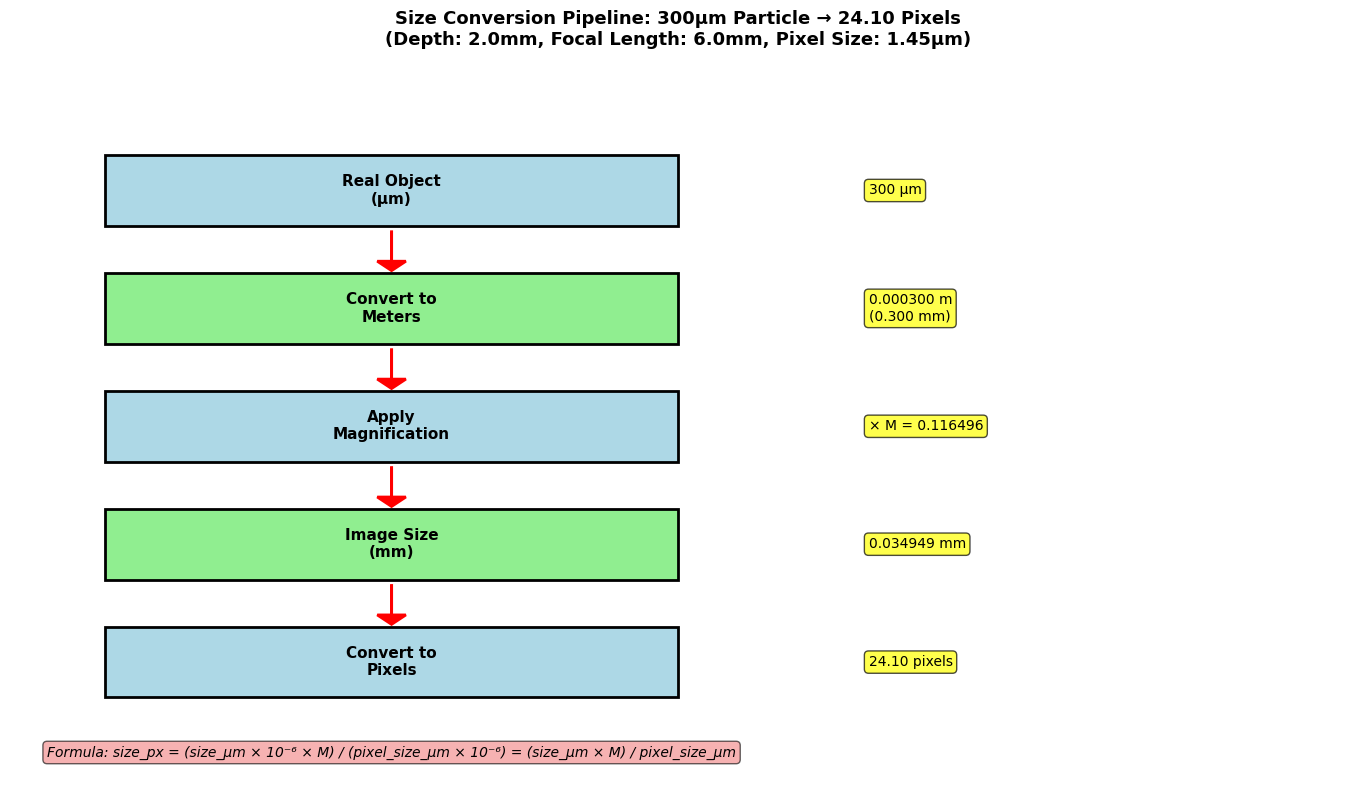


✓ The 'Size(μm)' is the REAL PHYSICAL SIZE of the microplastic particle
✓ After magnification and pixel conversion, it appears as 24.10 pixels on the image


In [30]:
# Detailed step-by-step size conversion example
print("=" * 80)
print("SIZE CONVERSION: REAL OBJECT → IMAGE PIXELS")
print("=" * 80)

# Example particle
example_real_size_um = 300  # micrometers
example_depth = 2.0  # mm

# Step 1: Real size in micrometers
print(f"\n📏 STEP 1: Real Physical Size")
print(f"   Microplastic particle size = {example_real_size_um} μm")
print(f"   (This is the actual size in the water)")

# Step 2: Convert to meters
size_meters = example_real_size_um * 1e-6
print(f"\n📐 STEP 2: Convert to Meters")
print(f"   {example_real_size_um} μm × 10⁻⁶ = {size_meters} m")
print(f"   = {size_meters * 1000} mm")

# Step 3: Calculate magnification
apparent_depth = example_depth / N_WATER
d_o = 50 + apparent_depth
M = FOCAL_LENGTH_MM / d_o
print(f"\n🔬 STEP 3: Calculate Magnification")
print(f"   Depth in water = {example_depth} mm")
print(f"   Apparent depth (refraction) = {apparent_depth:.3f} mm")
print(f"   Object distance = 50 + {apparent_depth:.3f} = {d_o:.3f} mm")
print(f"   Magnification M = {FOCAL_LENGTH_MM} / {d_o:.3f} = {M:.6f}")

# Step 4: Image size on sensor
image_size_m = size_meters * M
image_size_mm = image_size_m * 1000
print(f"\n📷 STEP 4: Image Size on Sensor")
print(f"   Image size = {size_meters} m × {M:.6f}")
print(f"   = {image_size_m:.9f} m")
print(f"   = {image_size_mm:.6f} mm")

# Step 5: Convert to pixels
pixel_pitch_m = PIXEL_SIZE_UM * 1e-6
size_pixels = image_size_m / pixel_pitch_m
print(f"\n🖼️ STEP 5: Convert to Pixels")
print(f"   Pixel pitch = {PIXEL_SIZE_UM} μm = {pixel_pitch_m:.9f} m")
print(f"   Size in pixels = {image_size_m:.9f} / {pixel_pitch_m:.9f}")
print(f"   = {size_pixels:.2f} pixels")

# Verify with function
size_px_function = micrometers_to_pixels(example_real_size_um, FOCAL_LENGTH_MM, example_depth)
print(f"\n✓ Verification with function: {size_px_function:.2f} pixels")
print(f"✓ Match: {abs(size_pixels - size_px_function) < 0.01}")

print("\n" + "=" * 80)

# Visual representation
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Define stages
stages = ['Real Object\n(μm)', 'Convert to\nMeters', 'Apply\nMagnification', 
          'Image Size\n(mm)', 'Convert to\nPixels']
y_positions = [5, 4, 3, 2, 1]

# Draw flow diagram
for i, (stage, y) in enumerate(zip(stages, y_positions)):
    # Draw box
    box_color = 'lightblue' if i % 2 == 0 else 'lightgreen'
    rect = plt.Rectangle((0.5, y - 0.3), 3, 0.6, facecolor=box_color, 
                         edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    
    # Add stage label
    ax.text(2, y, stage, ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Add values
    if i == 0:
        value_text = f'{example_real_size_um} μm'
    elif i == 1:
        value_text = f'{size_meters:.6f} m\n({size_meters * 1000:.3f} mm)'
    elif i == 2:
        value_text = f'× M = {M:.6f}'
    elif i == 3:
        value_text = f'{image_size_mm:.6f} mm'
    elif i == 4:
        value_text = f'{size_pixels:.2f} pixels'
    
    ax.text(4.5, y, value_text, ha='left', va='center', fontsize=10, 
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Draw arrow
    if i < len(stages) - 1:
        ax.arrow(2, y - 0.35, 0, -0.25, head_width=0.15, head_length=0.08, 
                fc='red', ec='red', linewidth=2)

# Add formulas
ax.text(2, 0.2, 
       f'Formula: size_px = (size_μm × 10⁻⁶ × M) / (pixel_size_μm × 10⁻⁶) = (size_μm × M) / pixel_size_μm',
       ha='center', fontsize=10, style='italic',
       bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.6))

ax.set_xlim(0, 7)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title(f'Size Conversion Pipeline: {example_real_size_um}μm Particle → {size_pixels:.2f} Pixels\n' + 
            f'(Depth: {example_depth}mm, Focal Length: {FOCAL_LENGTH_MM}mm, Pixel Size: {PIXEL_SIZE_UM}μm)',
            fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"\n✓ The 'Size(μm)' is the REAL PHYSICAL SIZE of the microplastic particle")
print(f"✓ After magnification and pixel conversion, it appears as {size_pixels:.2f} pixels on the image")